In [91]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches

# ===== 设置全局学术图表样式 =====
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 16
mpl.rcParams['axes.linewidth'] = 1.2
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['hatch.linewidth'] = 0.8 

# ===== 平滑 =====
def smooth(y, window=7):
    y = np.asarray(y, dtype=float)
    if window <= 1:
        return y
    pad = window // 2
    y_pad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    return np.convolve(y_pad, kernel, mode="valid")

# ===== 读取单个方法日志 =====
def load_log(npz_path):
    data = np.load(npz_path, allow_pickle=True)
    return {
        "round_idx": data["round_idx"],
        "test": data["global_test_r2"],
        "client1": data["client_24_val_r2"],
        "client2": data["client_25_val_r2"],
        "client3": data["client_26_val_r2"],
    }

# ===== 主函数 =====
def plot_schedule_figure_custom(method_files, turn_data, save_name, smooth_window=7):
    logs = {method: load_log(path) for method, path in method_files.items()}
    first_method = list(logs.keys())[0]
    rounds = logs[first_method]["round_idx"]

    method_styles = {
        "RetroFL":  {"color": "#4C72B0", "ls": "-",  "zorder": 4},
        "FedAvg [10]":   {"color": "#8172B2", "ls": "--", "zorder": 3},
        "FedProx [40]":  {"color": "#55A868", "ls": "-.", "zorder": 2},
        "Scaffold [41]": {"color": "#C44E52", "ls": ":",  "zorder": 1},
    }

    fig, axes = plt.subplots(
        5, 1, 
        figsize=(10, 11),
        sharex=True,
        gridspec_kw={"height_ratios": [1, 1, 1, 1, 0.3]} 
    )

    metric_info = [
        ("test", "Global Test $R^2$"),
        ("client1", "Client 1 $R^2$"),
        ("client2", "Client 2 $R^2$"),
        ("client3", "Client 3 $R^2$"),
    ]

    # 统一使用一种底纹颜色 (浅灰色 #999999)
    bg_styles = [
        {"hatch": "////",     "color": "#999999"}, # Client 1
        {"hatch": "xxxx", "color": "#999999"}, # Client 2
        {"hatch": "\\\\\\\\",     "color": "#999999"}, # Client 3
    ]

    # ===== 前4张：绘制精度曲线和纯底纹 =====
    for i, (ax, (metric_key, ylabel)) in enumerate(zip(axes[:4], metric_info)):
        
        if i > 0:
            client_idx = i - 1
            style = bg_styles[client_idx]
            spans = turn_data[client_idx]
            
            for start, end in spans:
                ax.axvspan(
                    start, end, 
                    facecolor="none",          
                    edgecolor=style["color"], # 浅灰底纹线
                    alpha=0.6,                # 透明度 0.6
                    hatch=style["hatch"],
                    linewidth=0,              # 无边框
                    zorder=0
                )

        for method_name, log in logs.items():
            y_raw = log[metric_key]
            style_method = method_styles.get(method_name, {"color": "black", "ls": "-", "zorder": 1})
            
            if smooth_window is not None and smooth_window > 1:
                y_smooth = smooth(y_raw, window=smooth_window)
                ax.plot(rounds, y_raw, color=style_method["color"], alpha=0.15, linewidth=0.8, zorder=style_method["zorder"])
            else:
                y_smooth = y_raw

            ax.plot(
                rounds, y_smooth,
                linewidth=2.0,
                color=style_method["color"],
                linestyle=style_method["ls"],
                label=method_name,
                alpha=0.95,
                zorder=style_method["zorder"]+10
            )

        ax.set_ylabel(ylabel, fontweight='bold')
        ax.set_ylim(0, 1.05)
        ax.set_xlim(0, 600)
        ax.grid(True, axis="y", linestyle="--", alpha=0.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # ===== 图例 =====
    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(
        handles, labels, 
        loc="lower right", 
        ncol=2,
        frameon=True,
        fontsize=16,
        facecolor='white', framealpha=0.9, edgecolor='black'
    )

    # ===== 第5张：上线时间纯底纹甘特图 (样式与上方完全统一) =====
    ax = axes[4]
    y_positions = [2, 1, 0]
    node_order = ["Client 1", "Client 2", "Client 3"]

    for y, client_spans, style in zip(y_positions, turn_data, bg_styles):
        xranges = [(start, end - start) for start, end in client_spans]
        
        ax.broken_barh(
            xranges, 
            (y - 0.35, 0.7),         
            facecolors="none",       
            edgecolors=style["color"], # 严格对齐：浅灰色
            hatch=style["hatch"],
            linewidth=0,               # 严格对齐：取消实线外框，只留底纹
            alpha=0.6                  # 严格对齐：透明度降到 0.6
        )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(node_order)
    ax.tick_params(axis='y', length=0) 
    ax.set_xlabel("Global Round", fontsize=16, fontweight='bold')
    ax.set_xlim(0, 600)
    ax.set_ylim(-0.8, 2.8) 
    
    ax.grid(True, axis="x", linestyle=":", alpha=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False) 

    plt.tight_layout(rect=[0, 0, 1, 1])
    plt.savefig(save_name.replace(".png", ".pdf"), dpi=300, bbox_inches="tight")
    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

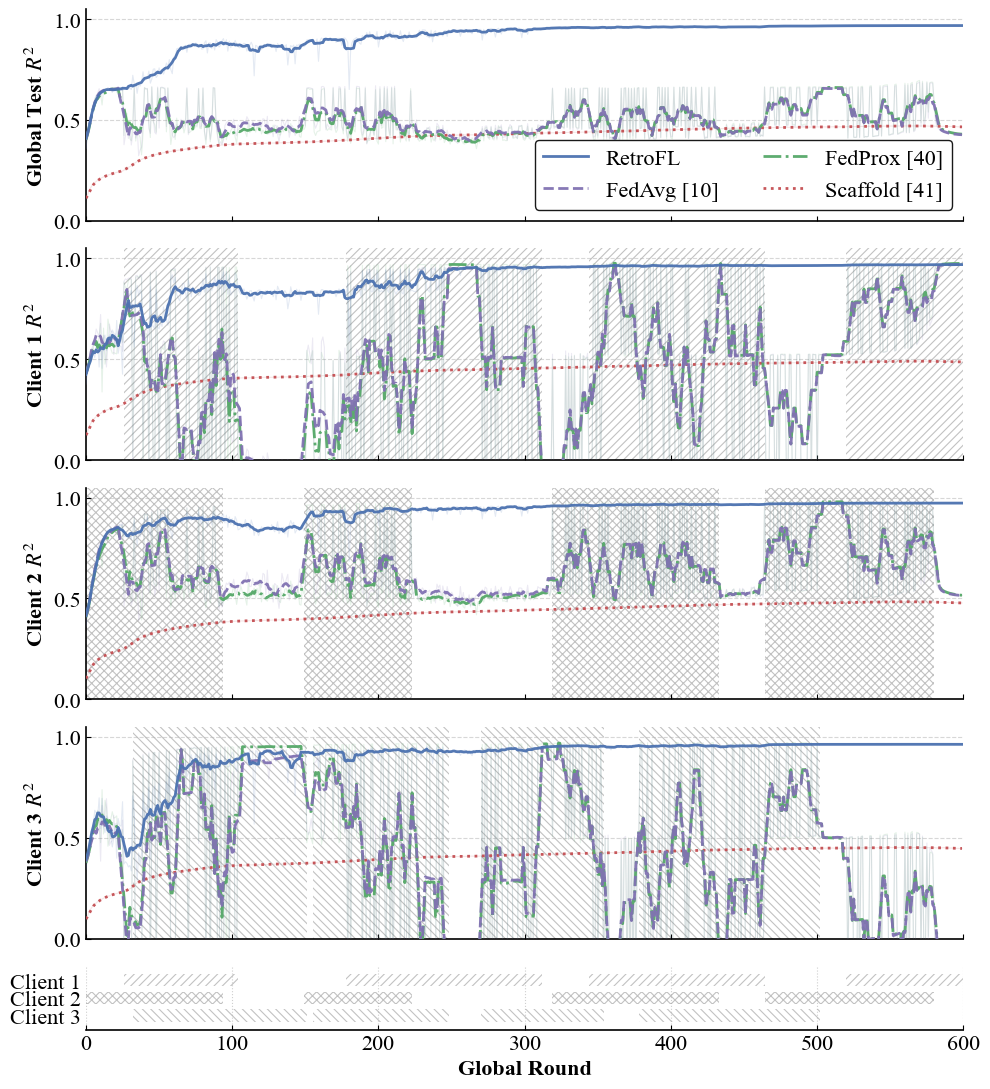

In [92]:
turn_random = [
    np.array([[26, 104], [178, 312], [344, 464], [520, 600]]),
    np.array([[0, 94], [149, 223], [319, 433], [464, 580]]),
    np.array([[32, 151], [155, 248], [270, 354], [378, 502]]),
]

random_method_files = {
    "RetroFL": "./forgetting_logs/retrofl_random_forgetting_log.npz",
    "FedAvg [10]": "./forgetting_logs/fedavg_random_forgetting_log.npz",
    "FedProx [40]": "./forgetting_logs/fedprox_random_forgetting_log.npz",
    "Scaffold [41]": "./forgetting_logs/scaffold_random_forgetting_log.npz",
}

plot_schedule_figure_custom(random_method_files, turn_random, save_name="random_schedule.png", smooth_window=7)

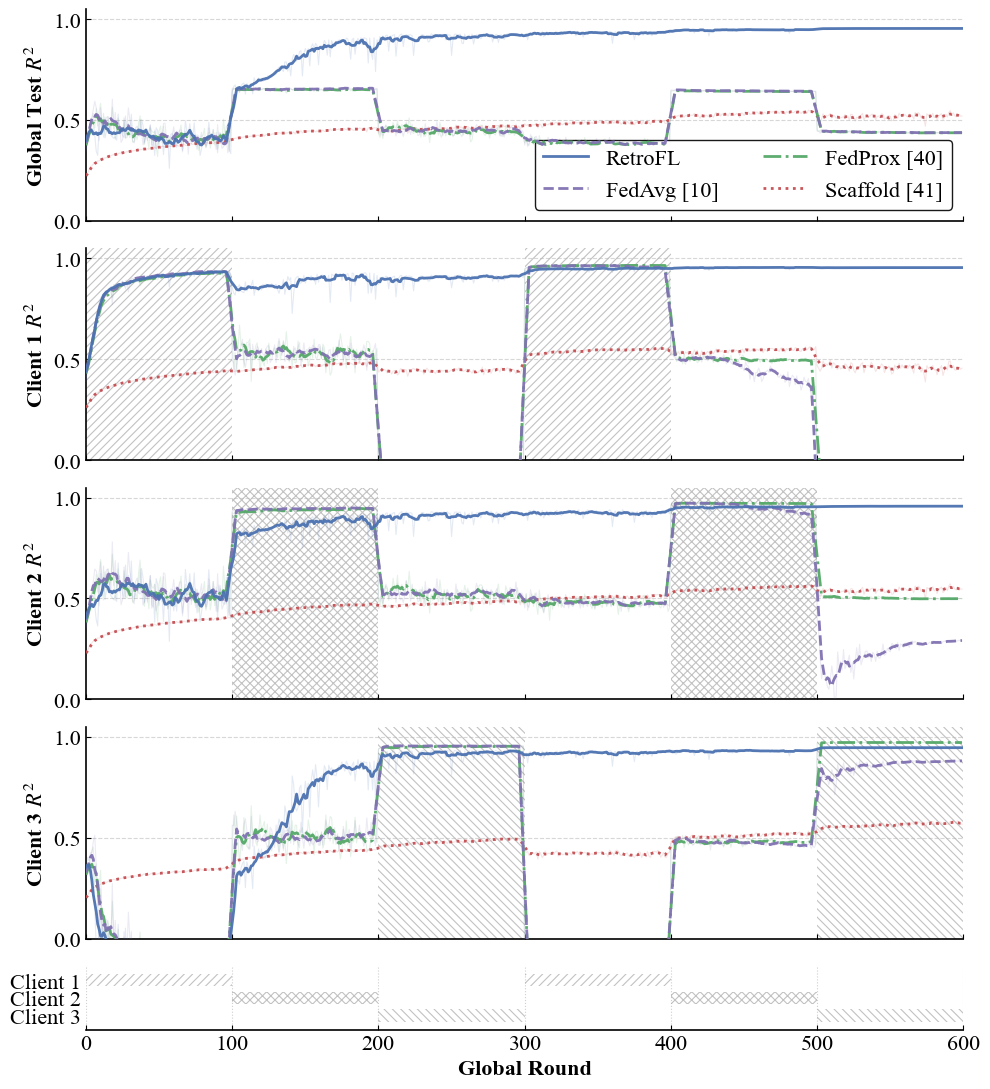

In [93]:
turn_continue = [
    np.array([[0, 100], [300, 400]]),
    np.array([[100, 200], [400, 500]]),
    np.array([[200, 300], [500, 600]]),
]

continue_method_files = {
    "RetroFL": "./forgetting_logs/retrofl_continue_forgetting_log.npz",
    "FedAvg [10]": "./forgetting_logs/fedavg_continue_forgetting_log.npz",
    "FedProx [40]": "./forgetting_logs/fedprox_continue_forgetting_log.npz",
    "Scaffold [41]": "./forgetting_logs/scaffold_continue_forgetting_log.npz",
}

plot_schedule_figure_custom(continue_method_files, turn_continue, save_name="continue_schedule.png", smooth_window=7)